# Lesson 2: Structural Analysis

[`01_introduction.ipynb`](01_introduction.ipynb) showed that the MFE
structure is just the single most probable structure, and that the
pair-probability matrix can reveal real competition between alternatives.
This notebook makes that competition concrete by enumerating the alternatives
themselves, and extends the toolkit to **multi-strand complexes**.

**By the end of this notebook you will be able to:**

- Enumerate near-optimal structures with `compute=["subopt"]` and an energy
  gap, and read an energy-level diagram of the results.
- Explain why a sequence can have several structurally very different
  near-optimal folds.
- Build a multi-strand `Complex` and read its dot-parens-**plus** notation
  (the `+` marking strand breaks).
- Read a pair-probability heatmap for a multi-strand complex, including the
  base pair that spans the strand break (the "nick").

**Prerequisites:** [`01_introduction.ipynb`](01_introduction.ipynb) - `Model`,
`Strand`, `Complex`, `complex_analysis`, MFE, pair-probability matrices.


## Introduction

At the end of lesson 1, the 21-nt sequence `GGGAAACCCAAAGGGAAACCC` had a pair
matrix where the strongest off-diagonal entry in each stem was only
0.69-0.73. That means the MFE structure is just one of *several* structures
that together make up most of the ensemble. This notebook answers the natural
follow-up question: **what do those other structures actually look like?**

The second half of the notebook moves from one strand to two. Real
applications - probes binding targets, strand-displacement gates, aptamer-
ligand complexes - involve multiple strands forming one complex, and NUPACK's
dot-parens-plus notation is how it represents that.

### Roadmap

1. Enumerate suboptimal structures for a single strand with `subopt` and an
   energy gap.
2. Visualize those structures as an energy-level diagram, and compare the two
   lowest-energy folds side by side with `forgi`.
3. Build a two-strand duplex `Complex` and read its dot-parens-plus structure.
4. Visualize the duplex pair-probability matrix, including the strand-break
   "nick".


## Setup

Same model as lesson 1: RNA at 37 deg C in 1 M Na$^+$, with the shared seaborn
theme and `forgi` for structure diagrams.


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import forgi.graph.bulge_graph as fgb
import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", palette="deep")

model = Model(material="rna", celsius=37, sodium=1.0)


def plot_structure(sequence, structure, ax, title):
    '''Draw a forgi secondary-structure diagram for one dot-bracket structure.'''
    bg = fgb.BulgeGraph.from_dotbracket(structure, seq=sequence)
    fvm.plot_rna(bg, ax=ax, lighten=0.7, text_kwargs={"fontweight": "black"})
    ax.set_title(title)
    ax.set_axis_off()


## Theory: suboptimal structures and dot-parens-plus

**Suboptimal structures.** `compute=["subopt"]` asks NUPACK to enumerate
*every* structure $s$ whose free energy is within a chosen **energy gap**
$\Delta$ of the MFE energy:

$$
G(s) \le G(\hat{s}) + \Delta .
$$

This is a deterministic, exhaustive enumeration (not sampling) - if $\Delta$
is large enough, it returns every locally relevant alternative, sorted by
energy. A small $\Delta$ (e.g. 0.5 kcal/mol) might return only the MFE
structure itself; a larger one reveals the competing folds that a
pair-probability matrix hints at but doesn't show explicitly. `options=
{"energy_gap": <value>}` sets $\Delta$ in kcal/mol.

**Dot-parens-plus notation.** A `Complex` with $k$ strands is represented as
$k$ dot-parens segments joined by `+`, in the order the strands were passed to
`Complex`. For example `(((((((((+)))))))))` describes a two-strand complex
where strand 1 contributes the first 9 characters and strand 2 the last 9;
the `+` itself is not a nucleotide, just a separator. Base pairs can span the
`+` exactly like they span any other position - NUPACK numbers nucleotides
continuously across the whole complex (0-based), skipping the `+` characters.


## Worked example 1: enumerating alternatives to the MFE

We reuse `seq2 = "GGGAAACCCAAAGGGAAACCC"` from lesson 1, whose MFE structure
`(((...(((...)))...)))` had pair probabilities around 0.7 in its stems. Let's
ask for every structure within 3 kcal/mol of the MFE energy.


In [2]:
seq2 = "GGGAAACCCAAAGGGAAACCC"
strand2 = Strand(seq2, name="s2")
complex2 = Complex([strand2], name="c2")

result2 = complex_analysis(
    complexes=[complex2],
    model=model,
    compute=["mfe", "subopt"],
    options={"energy_gap": 3.0},
)[complex2]

mfe2 = result2.mfe[0]

# subopt can contain duplicate (structure, energy) pairs; keep unique structures
subopt_by_structure = {}
for s in result2.subopt:
    subopt_by_structure[str(s.structure)] = float(s.energy)

subopt_df = (
    pd.DataFrame(
        {"structure": list(subopt_by_structure.keys()), "energy": list(subopt_by_structure.values())}
    )
    .sort_values("energy")
    .reset_index(drop=True)
)
subopt_df["is_mfe"] = subopt_df["structure"] == str(mfe2.structure)
display(subopt_df)


,structure,energy,is_mfe
0,(((...(((...)))...))),-5.800000,True
1,(((...)))...(((...))),-4.673164,False
2,(((...)))...((....)).,-4.621963,False
3,.((...(((...)))...)).,-3.962439,False
4,(((...((.....))...))),-3.200000,False
5,(((....((....))...))),-3.000000,False
6,(((...)))............,-2.937886,False


Seven structurally distinct folds lie within 3 kcal/mol of the MFE - everything
from the MFE's nested double hairpin down to a structure with only the first
hairpin formed. Energies alone don't show *how different* these structures
are from each other; a diagram does.


## Visualization: an energy-level diagram

A horizontal lollipop chart, one row per suboptimal structure sorted by
energy, shows the energy landscape near the MFE at a glance - which
alternatives are close in energy, and which is the MFE (highlighted).


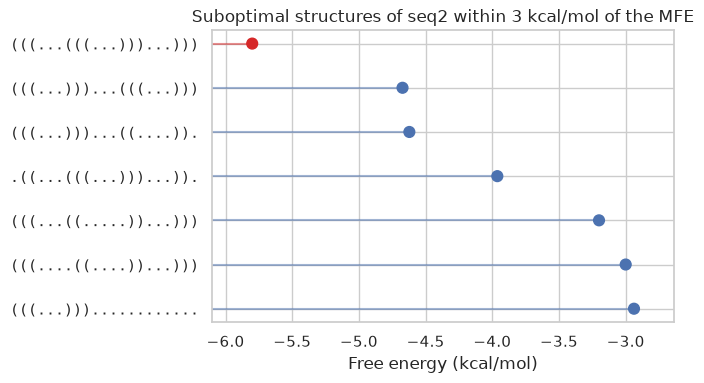

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#d62728" if is_mfe else "#4c72b0" for is_mfe in subopt_df["is_mfe"]]
y = np.arange(len(subopt_df))

ax.hlines(y, xmin=subopt_df["energy"].min() - 0.3, xmax=subopt_df["energy"], color=colors, alpha=0.5)
ax.scatter(subopt_df["energy"], y, color=colors, zorder=3, s=60)

ax.set_yticks(y)
ax.set_yticklabels(subopt_df["structure"], fontfamily="monospace")
ax.invert_yaxis()
ax.set_xlabel("Free energy (kcal/mol)")
ax.set_title("Suboptimal structures of seq2 within 3 kcal/mol of the MFE")
ax.set_xlim(subopt_df["energy"].min() - 0.3, subopt_df["energy"].max() + 0.3)
fig.tight_layout()
plt.show()


**Interpretation.** The MFE (red, $-5.80$ kcal/mol) is closely followed by a
structure at $-4.67$ kcal/mol that forms two **separate** hairpins instead of
one nested pair - notice it shares essentially no base pairs with the MFE.
Several other alternatives only partially form one of the two hairpins. A gap
of just over 1 kcal/mol between the top two structures corresponds to roughly
a 6-fold difference in Boltzmann weight at 37 deg C - large, but not
overwhelming, which is consistent with the pair matrix in lesson 1 showing
each stem confidently formed only about 70% of the time.


## Visualization: the two lowest-energy structures side by side

The energy-level diagram tells us the top two structures are close in energy
but different in topology. `forgi` diagrams make that topology difference
immediate.


findfont: Failed to find font weight black, now using 700.


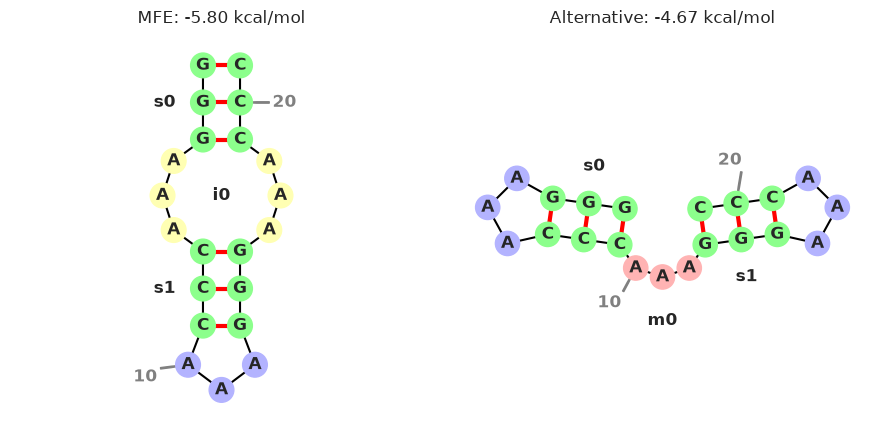

In [4]:
top_two = subopt_df.iloc[:2]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, (_, row) in zip(axes, top_two.iterrows()):
    label = "MFE" if row["is_mfe"] else "Alternative"
    plot_structure(seq2, row["structure"], ax, f"{label}: {row['energy']:.2f} kcal/mol")
fig.tight_layout()
plt.show()


**Interpretation.** The MFE (left) is a nested pair of hairpins - one stem
encloses the other. The next-best structure (right) has the same total number
of base pairs, but arranged as **two side-by-side hairpins** sharing no base
pairs with the MFE at all. A single dot-bracket string or pair matrix doesn't
convey this "completely different shape, similar energy" relationship nearly
as directly as the two diagrams do.


## Worked example 2: a two-strand complex

Now we move from one strand to two. `a = "GGGAAACCC"` and
`b = "GGGUUUCCC"` are exact reverse complements of each other, so we expect
them to form a fully base-paired duplex.


In [5]:
strand_a = Strand("GGGAAACCC", name="a")
strand_b = Strand("GGGUUUCCC", name="b")
duplex = Complex([strand_a, strand_b], name="duplex")

result_duplex = complex_analysis(
    complexes=[duplex],
    model=model,
    compute=["pfunc", "mfe", "pairs"],
)[duplex]

mfe_duplex = result_duplex.mfe[0]

print("Complex:", duplex.name, "- strands:", [s.name for s in duplex.strands])
print("Total nucleotides:", duplex.nt())
print("MFE structure:", mfe_duplex.structure)
print(f"MFE energy:           {mfe_duplex.energy:.2f} kcal/mol")
print(f"Ensemble free energy: {result_duplex.free_energy:.2f} kcal/mol")


Complex: duplex - strands: ['a', 'b']
Total nucleotides: 18
MFE structure: (((((((((+)))))))))
MFE energy:           -17.98 kcal/mol
Ensemble free energy: -18.05 kcal/mol


The MFE structure `(((((((((+)))))))))` is a single uninterrupted run of 9
`(` characters (strand `a`, indices 0-8), a `+` marking the strand break, and
9 `)` characters (strand `b`, indices 9-17). Reading the nesting: index 0
pairs with index 17, index 1 with index 16, ..., and the **innermost** pair is
$(8, 9)$ - the two nucleotides immediately on either side of the strand break.
That's expected for a clean duplex: the break sits where a hairpin loop would
otherwise be, at the "far end" of the helix from the 5' end of strand `a`.


## Visualization: the duplex pair-probability matrix

Plotting $P_{ij}$ for the 18-nt complex shows the duplex as a strong
anti-diagonal band, same as the hairpin stem in lesson 1 - except now the band
crosses a strand boundary. A dashed line marks where strand `a` ends and
strand `b` begins.


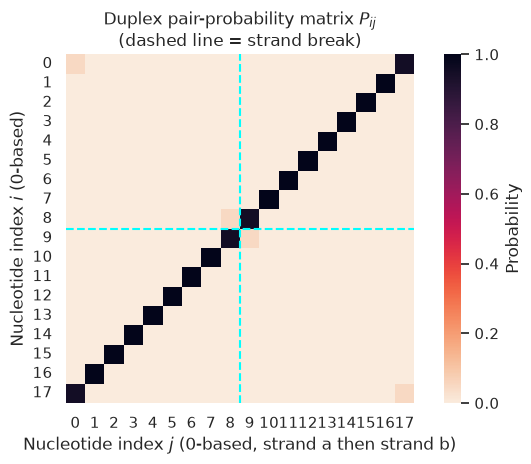

In [6]:
pairs_duplex = result_duplex.pairs.to_array()
n_a = strand_a.nt()  # length of strand a = index of the strand break

fig, ax = plt.subplots(figsize=(6.5, 4.8))
sns.heatmap(
    pairs_duplex,
    cmap="rocket_r",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Probability"},
    ax=ax,
)
plt.setp(ax.get_yticklabels(), rotation=0)
for pos in (n_a,):
    ax.axhline(pos, color="cyan", linestyle="--", linewidth=1.5)
    ax.axvline(pos, color="cyan", linestyle="--", linewidth=1.5)
ax.set_title("Duplex pair-probability matrix $P_{ij}$\n(dashed line = strand break)")
ax.set_xlabel("Nucleotide index $j$ (0-based, strand a then strand b)")
ax.set_ylabel("Nucleotide index $i$ (0-based)")
fig.tight_layout()
plt.show()


**Interpretation.** The full anti-diagonal band (probability $\ge 0.95$
almost everywhere) confirms the duplex is essentially fully formed. The one
exception is the innermost pair $(8, 9)$ - exactly at the strand break - which
is paired with probability 0.95 rather than $\ge 0.999$ like the rest, with a
small (0.05) chance of being unpaired instead. This is the same kind of "end
effect" as the terminal-pair fraying in lesson 1, except here it occurs at an
internal nick rather than a true 3'/5' end, because the nick is the
least-constrained point in an otherwise fully stacked helix.


## A note on strand order and identical strands

`Complex([strand_a, strand_b], ...)` and `Complex([strand_b, strand_a], ...)`
describe the **same physical molecule**, but NUPACK treats them as different
complex objects with different dot-parens-plus numbering (strand `a` is
nucleotides 0-8 in the first, 9-17 in the second). When you build complexes
for tube analysis (lesson 5 onward), pick one consistent strand order and
stick with it so results stay comparable.

A complex can also contain the **same strand more than once** - e.g. a
homodimer `Complex([strand_a, strand_a], ...)`. NUPACK still numbers all
nucleotides continuously and separates the two copies with `+`; the resulting
structure can be symmetric (both copies forming the same shape) or not,
depending on the sequence.


## Best practices and common pitfalls

- **Choose the energy gap deliberately.** Too small (e.g. 0.5 kcal/mol) and
  `subopt` may return only the MFE; too large and the list grows quickly
  (the number of structures within $\Delta$ grows roughly exponentially with
  $\Delta$ for longer sequences). Start small and increase until you see the
  qualitative alternatives you care about.
- **Deduplicate `subopt` output.** NUPACK can list the same `(structure,
  energy)` pair more than once (e.g. from degenerate energy contributions);
  group by the structure string before counting or plotting, as
  `subopt_by_structure` does above.
- **The `+` is not a nucleotide.** When converting a dot-parens-plus string
  for another tool (like `forgi`, which uses `&` for multi-strand input),
  strip or translate the separator from *both* the structure and the
  sequence, consistently.
- **Strand order matters for indexing**, even though it doesn't change the
  physical complex - decide on an order convention before building many
  related complexes (lessons 5-10 rely on this).


## Summary

In this notebook you:

1. Enumerated suboptimal structures with `compute=["subopt"]` and an energy
   gap, and read the results as an energy-level diagram.
2. Saw that the MFE and its closest competitor can be nearly tied in energy
   while sharing essentially no base pairs - exactly the kind of competition
   the lesson 1 pair matrix hinted at.
3. Built a two-strand `Complex`, read its dot-parens-plus structure, and
   identified the strand break (`+`) and the "nick" base pair next to it.
4. Visualized a multi-strand pair-probability matrix with the strand
   boundary marked.

**Next:** [`03_probabilities.ipynb`](03_probabilities.ipynb) goes from
*enumerating* structures to *sampling* them from the Boltzmann ensemble, and
looks at how the ensemble itself shifts with temperature.


## Exercises

1. Re-run the `subopt` computation for `seq2` with `energy_gap=1.0` and then
   `energy_gap=5.0`. How many unique structures do you get in each case? At
   what energy gap does the "two side-by-side hairpins" alternative first
   appear?
2. Build `Complex([strand_b, strand_a], name="duplex_ba")` (the strands in the
   opposite order) and re-run the analysis. Confirm the MFE energy is the same
   as `duplex`, but write out the new dot-parens-plus structure - which
   indices does the strand break fall between now?
